# TA-XLM-R v4 — Bangla Script Only
## Transliteration-Aware XLM-RoBERTa — Filtered to Pure Bangla Text

**Changes from original v4:**
- Dataset columns updated: `Banglish_Text` → `text`, `Label` → `label`
- **Bangla-only filter**: only rows where Bangla chars > Latin chars are kept
- Normalization adapted: Banglish transliteration map removed; Bangla Unicode normalization used instead
- Section 15 cross-script analysis replaced with per-class F1 breakdown
- Robustness test updated to Bangla Unicode noise (vowel diacritic dropout)
- Output filenames updated to `*_bangla.*`

**4 Sentiment Classes:**
Literary Appreciation | Analytical Reflection | Constructive Critique | Strong Critique

## 1. Install & Import

In [1]:
import subprocess, sys
import torch
print(f'Current torch: {torch.__version__}')
print(f'CUDA available: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

!pip install torch==2.1.0 torchvision==0.16.0 --index-url https://download.pytorch.org/whl/cu118 -q
!pip install transformers==4.40.0 scikit-learn pandas numpy matplotlib seaborn -q
print('\nInstallation complete. RESTART KERNEL if first run, then re-run from cell 2.')

Current torch: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4
ERROR: Could not find a version that satisfies the requirement torch==2.1.0 (from versions: 2.2.0+cu118, 2.2.1+cu118, 2.2.2+cu118, 2.3.0+cu118, 2.3.1+cu118, 2.4.0+cu118, 2.4.1+cu118, 2.5.0+cu118, 2.5.1+cu118, 2.6.0+cu118, 2.7.0+cu118, 2.7.1+cu118)
ERROR: No matching distribution found for torch==2.1.0
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.6/137.6 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.0/9.0 MB 91.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 37.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 74.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sentence-transformers 5.2.3 requires transformers<6.0.0,>=4.41.0, but you have transformers 4.40.0 which is incompatible.

Installation complet

In [2]:
import os, re, json, random, copy
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.optim.swa_utils import AveragedModel, SWALR, update_bn

from transformers import AutoTokenizer, AutoModel, get_cosine_schedule_with_warmup
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    confusion_matrix, cohen_kappa_score
)

matplotlib.rcParams.update({
    'figure.dpi': 150, 'font.size': 11,
    'axes.grid': True, 'grid.alpha': 0.3,
    'axes.spines.top': False, 'axes.spines.right': False,
})

# ── CUDA Safety ──────────────────────────────────────────────────────────────
if torch.cuda.is_available():
    try:
        _t = torch.zeros(2, 2).cuda()
        _t2 = torch.nn.LSTM(2, 2).cuda()
        del _t, _t2
        DEVICE = torch.device('cuda')
        print(f'CUDA OK — GPU: {torch.cuda.get_device_name(0)}')
    except Exception as e:
        print(f'CUDA test failed: {e}. Falling back to CPU.')
        DEVICE = torch.device('cpu')
else:
    DEVICE = torch.device('cpu')
    print('CUDA not available — using CPU.')
print(f'Device: {DEVICE} | PyTorch: {torch.__version__}')

# ── Config ───────────────────────────────────────────────────────────────────
CFG = {
    'xlmr_model'     : 'xlm-roberta-base',
    'max_len'        : 160,
    'batch_size'     : 16,
    'grad_accum'     : 4,
    'lr_embed'       : 0.0,
    'lr_lower'       : 1e-5,
    'lr_upper'       : 2e-5,
    'lr_head'        : 1e-4,
    'epochs'         : 20,
    'patience'       : 6,
    'dropout'        : 0.2,
    'char_emb_dim'   : 64,
    'char_out_dim'   : 384,
    'num_heads'      : 8,
    'num_classes'    : 4,
    'label_smoothing': 0.1,
    'mixup_alpha'    : 0.2,
    'warmup_ratio'   : 0.15,
    'test_size'      : 0.15,
    'val_size'       : 0.15,
    'seeds'          : [42, 123, 7],
    'swa_start_frac' : 0.75,
    'swa_lr'         : 5e-6,
    'unfreeze_from_layer': 6,
}

LABEL2ID = {
    'Literary Appreciation': 0,
    'Analytical Reflection': 1,
    'Constructive Critique': 2,
    'Strong Critique'      : 3,
}
ID2LABEL  = {v: k for k, v in LABEL2ID.items()}
SHORT_LBL = ['Lit. App.', 'Anal. Ref.', 'Cons. Crit.', 'Str. Crit.']
print('Configuration ready.')

CUDA OK — GPU: Tesla T4
Device: cuda | PyTorch: 2.10.0+cu128
Configuration ready.


## 2. Load Dataset — Bangla Script Only

In [3]:
dataset_path = "/kaggle/input/datasets/rafsanpronoy/bangla-book-review/Bangla_BBBRC old Dataset.csv"
print(f'Using: {dataset_path}')

Using: /kaggle/input/datasets/rafsanpronoy/bangla-book-review/Bangla_BBBRC old Dataset.csv


In [4]:
df_raw = pd.read_csv(dataset_path)
print(f'Raw shape: {df_raw.shape}')
print(df_raw.head(3))
print('Columns:', df_raw.columns.tolist())

Raw shape: (12659, 3)
   ID                                        Bangla_Text  \
0   1  কর্তৃক লিখিত রিভিউটি উনার নিজের নয়। এটি আগেই প...   
1   2                                     সুন্দর একটি বই   
2   3  গল্পের মধ্যে হারিয়ে যাওয়ার সুযোগ আছে। খুবই ভাল...   

                   Label  
0        Strong Critique  
1  Literary Appreciation  
2  Literary Appreciation  
Columns: ['ID', 'Bangla_Text', 'Label']


In [5]:
df = df_raw.copy()
df.columns = [c.strip() for c in df.columns]

print('Actual columns:', df.columns.tolist())

# ── Auto-detect text and label columns ───────────────────────────────────────
def find_col(columns, candidates):
    for c in columns:
        if c.strip().lower() in [x.lower() for x in candidates]:
            return c
    return None

text_col  = find_col(df.columns, ['text', 'banglish_text', 'bangla_text', 'sentence', 'content', 'review'])
label_col = find_col(df.columns, ['label', 'sentiment', 'class', 'category'])

# Fallback: if still None, just pick by position
if text_col is None:
    text_col = df.columns[1]   # usually second column after ID
    print(f'Warning: text column not found by name, using positional fallback: {text_col}')
if label_col is None:
    label_col = df.columns[-1] # usually last column
    print(f'Warning: label column not found by name, using positional fallback: {label_col}')

print(f'Using text_col="{text_col}" | label_col="{label_col}"')

df['text']  = df[text_col].astype(str).str.strip()
df['label'] = df[label_col].str.strip().map(LABEL2ID)
df = df.dropna(subset=['text', 'label'])
df['label'] = df['label'].astype(int)

# ── Script detector ───────────────────────────────────────────────────────────
def detect_script(text):
    bangla_chars = len(re.findall(r'[\u0980-\u09FF]', text))
    latin_chars  = len(re.findall(r'[a-zA-Z]', text))
    if bangla_chars > latin_chars: return 'Bangla'
    elif latin_chars > bangla_chars: return 'Banglish'
    return 'Mixed'

df['script'] = df['text'].apply(detect_script)

print('Full dataset script distribution:')
print(df['script'].value_counts())
print(f'Total rows before filter: {len(df)}')

# ── FILTER: keep Bangla-script rows only ──────────────────────────────────────
df_all = df.copy()
df     = df[df['script'] == 'Bangla'].copy()

df = df.sample(frac=1, random_state=42).reset_index(drop=True)
df['ID'] = df.index + 1

print(f'\nOriginal total : {len(df_all)}')
print(f'Bangla-only    : {len(df)}  ({len(df)/len(df_all)*100:.1f}% of dataset)')
print('\nLabel dist (Bangla only):', df['label'].value_counts().sort_index().to_dict())
print('Script dist (sanity check):', df['script'].value_counts().to_dict())
print()
print(df[['ID', 'text', 'label']].head(5))

Actual columns: ['ID', 'Bangla_Text', 'Label']
Using text_col="Bangla_Text" | label_col="Label"
Full dataset script distribution:
script
Bangla    12627
Mixed        32
Name: count, dtype: int64
Total rows before filter: 12659

Original total : 12659
Bangla-only    : 12627  (99.7% of dataset)

Label dist (Bangla only): {0: 8974, 1: 2436, 2: 806, 3: 411}
Script dist (sanity check): {'Bangla': 12627}

   ID                                               text  label
0   1  বইয়ের নাম: শেষ বেঞ্চের ছেলেটিলেখকের নাম: তাহস...      1
1   2  জীবনের সময় সেরা বই।এটি বাচ্চাদের পক্ষে সহজ।আম...      0
2   3  বাঙালি মুসলিম লেখকদের মধ্যে শ্রেষ্ঠ লেখন ইনি।অ...      0
3   4  বইটা বেশ কিছু মৌলিক আর ইন্টারেস্টিং প্রশ্ন দিয়...      0
4   5                                         চমৎকার বই!      0


## 3. Bangla Text Normalization
### Unicode normalization for pure Bangla script (Banglish transliteration map not needed)

In [6]:
# ── Bangla Unicode normalization ──────────────────────────────────────────────
# For pure Bangla text we:
#   1. Normalize whitespace
#   2. Strip non-Bangla/non-punctuation characters
#   3. Normalize common Bangla Unicode variants (hasanta, nukta, etc.)
# The Banglish transliteration map from v4 is intentionally omitted —
# it targets Latin-script spelling variants irrelevant to Bangla Unicode.

BANGLA_PUNCT = '।॥?!,.\'"()'

# Common Bangla Unicode variant normalization
BANGLA_NORM_MAP = [
    ('\u09DC', '\u09B0\u09BC'),   # ড় → ড + ়
    ('\u09DD', '\u09A2\u09BC'),   # ঢ় → ঢ + ়
    ('\u09DF', '\u09AF\u09BC'),   # য় → য + ়
]

def normalize_bangla(text: str) -> str:
    """Normalize pure Bangla Unicode text."""
    # Whitespace normalization
    text = re.sub(r'\s+', ' ', text).strip()
    # Apply Unicode variant normalization
    for src, tgt in BANGLA_NORM_MAP:
        text = text.replace(src, tgt)
    # Remove characters outside Bangla Unicode block and allowed punctuation
    allowed = r'[^\u0980-\u09FF\u0020' + re.escape(BANGLA_PUNCT) + r']'
    text = re.sub(allowed, ' ', text)
    # Final whitespace cleanup
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['text_norm'] = df['text'].apply(normalize_bangla)

print('Normalization complete. Sample (first 5 rows):')
for _, row in df.head(5).iterrows():
    print(f'  Raw : {row["text"]}')
    print(f'  Norm: {row["text_norm"]}')
    print()

Normalization complete. Sample (first 5 rows):
  Raw : বইয়ের নাম: শেষ বেঞ্চের ছেলেটিলেখকের নাম: তাহসিনুল ইসলামবইয়ের ধরন: কিশোর উপন্যাসপ্রকাশনী: সূচীপত্র প্রকাশনীপ্রচ্ছদ: রাজীব চৌধুরীপ্রচ্ছদ মূল্য: ১০০ টাকা মাত্রকাহিনী সংক্ষেপ:মোহনপুর হাইস্কুলের ক্লাস এইটের সবচেয়ে দুষ্টু আর খারাপ ছাত্র জহির। স্কুলের বাংলার শি
  Norm: বইয়ের নাম শেষ বেঞ্চের ছেলেটিলেখকের নাম তাহসিনুল ইসলামবইয়ের ধরন কিশোর উপন্যাসপ্রকাশনী সূচীপত্র প্রকাশনীপ্রচ্ছদ রাজীব চৌধুরীপ্রচ্ছদ মূল্য ১০০ টাকা মাত্রকাহিনী সংক্ষেপ মোহনপুর হাইস্কুলের ক্লাস এইটের সবচেয়ে দুষ্টু আর খারাপ ছাত্র জহির। স্কুলের বাংলার শি

  Raw : জীবনের সময় সেরা বই।এটি বাচ্চাদের পক্ষে সহজ।আমার ছোট ভাই এই বইটি পড়তে খুব আগ্রহী ছিলেন।এই বইটি পড়ার পরে, তিনি সন্তুষ্ট হয়েছেন।এবং আমার ছোট বোন, যার বয়স নয় বছর বয়সী, তিনি এই বইটি পড়তে খুব আগ্রহী ছিলেন।এই বইটি পড়ার পরে, তিনি সন্তুষ্ট হয়েছেন আমরা
  Norm: জীবনের সময় সেরা বই।এটি বাচ্চাদের পক্ষে সহজ।আমার ছোট ভাই এই বইটি পড়তে খুব আগ্রহী ছিলেন।এই বইটি পড়ার পরে, তিনি সন্তুষ্ট হয়েছেন।এবং আমার ছোট বোন, যার বয়স নয়

## 4. Character Vocabulary

In [7]:
def build_char_vocab(texts, max_chars=400):
    counter = Counter(ch for t in texts for ch in t)
    vocab   = {'<PAD>': 0, '<UNK>': 1}
    for ch, _ in counter.most_common(max_chars):
        vocab[ch] = len(vocab)
    return vocab

def text_to_char_ids(text, vocab, max_len=160):
    ids = [vocab.get(ch, vocab['<UNK>']) for ch in text[:max_len]]
    ids += [vocab['<PAD>']] * (max_len - len(ids))
    return ids

CHAR_VOCAB = build_char_vocab(df['text_norm'].tolist())
print(f'Char vocab size: {len(CHAR_VOCAB)}')
bangla_chars = [(ch, idx) for ch, idx in CHAR_VOCAB.items()
                if ch not in ('<PAD>', '<UNK>') and '\u0980' <= ch <= '\u09FF']
print(f'Bangla Unicode chars in vocab: {len(bangla_chars)}')

Char vocab size: 88
Bangla Unicode chars in vocab: 76


## 5. Dataset & DataLoader

In [8]:
TOKENIZER = AutoTokenizer.from_pretrained(CFG['xlmr_model'])

class BanglaDataset(Dataset):
    def __init__(self, dataframe, tokenizer, char_vocab, max_len):
        self.texts      = dataframe['text_norm'].tolist()
        self.labels     = dataframe['label'].tolist()
        self.tokenizer  = tokenizer
        self.char_vocab = char_vocab
        self.max_len    = max_len

    def __len__(self): return len(self.texts)

    def __getitem__(self, idx):
        text  = self.texts[idx]
        label = self.labels[idx]
        enc   = self.tokenizer(
            text, max_length=self.max_len,
            padding='max_length', truncation=True, return_tensors='pt'
        )
        char_ids = torch.tensor(
            text_to_char_ids(text, self.char_vocab, self.max_len),
            dtype=torch.long
        )
        return {
            'input_ids'      : enc['input_ids'].squeeze(0),
            'attention_mask' : enc['attention_mask'].squeeze(0),
            'char_ids'       : char_ids,
            'label'          : torch.tensor(label, dtype=torch.long),
        }

def make_loader(df_split, shuffle=False):
    ds = BanglaDataset(df_split, TOKENIZER, CHAR_VOCAB, CFG['max_len'])
    return DataLoader(ds, batch_size=CFG['batch_size'],
                      shuffle=shuffle, num_workers=0, pin_memory=True)

print('Dataset class ready.')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Dataset class ready.


## 6. TA-XLM-R v4 Architecture
### Char CNN + Mean-pooling + Cross-Modal Attention Fusion

In [9]:
class CharCNNEncoder(nn.Module):
    """
    Multi-scale char CNN: captures 2,3,4-gram character patterns.
    Output dim = out_dim (via projection).
    """
    def __init__(self, vocab_size, emb_dim, out_dim, dropout):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=0)
        self.dropout   = nn.Dropout(dropout)
        num_filters = out_dim // 3
        self.conv2 = nn.Conv1d(emb_dim, num_filters, kernel_size=2, padding=1)
        self.conv3 = nn.Conv1d(emb_dim, num_filters, kernel_size=3, padding=1)
        self.conv4 = nn.Conv1d(emb_dim, num_filters, kernel_size=4, padding=2)
        cnn_out = num_filters * 3
        self.proj = nn.Linear(cnn_out, out_dim)
        self.norm = nn.LayerNorm(out_dim)

    def forward(self, char_ids):
        x = self.dropout(self.embedding(char_ids))
        x = x.transpose(1, 2)
        c2 = F.relu(self.conv2(x)).max(dim=-1)[0]
        c3 = F.relu(self.conv3(x)).max(dim=-1)[0]
        c4 = F.relu(self.conv4(x)).max(dim=-1)[0]
        cat = torch.cat([c2, c3, c4], dim=-1)
        return self.norm(self.proj(cat))


class CrossModalFusion(nn.Module):
    """
    XLM-R mean-pool (768) + Char CNN (384) → cross-attention → (1152)
    """
    def __init__(self, xlmr_dim, char_dim, num_heads, dropout):
        super().__init__()
        fused_dim = xlmr_dim + char_dim
        self.xlmr_proj = nn.Linear(xlmr_dim, xlmr_dim)
        self.char_proj  = nn.Linear(char_dim,  char_dim)
        common = min(xlmr_dim, char_dim)
        self.to_common_x = nn.Linear(xlmr_dim, common)
        self.to_common_c = nn.Linear(char_dim,  common)
        self.mha = nn.MultiheadAttention(
            embed_dim=common, num_heads=num_heads,
            dropout=dropout, batch_first=True
        )
        self.from_common = nn.Linear(common, xlmr_dim)
        self.norm = nn.LayerNorm(fused_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, xlmr_vec, char_vec):
        xp = self.xlmr_proj(xlmr_vec).unsqueeze(1)
        cp = self.char_proj(char_vec).unsqueeze(1)
        xc = self.to_common_x(xp)
        cc = self.to_common_c(cp)
        attn_out, _ = self.mha(xc, cc, cc)
        attn_out = self.dropout(self.from_common(attn_out)).squeeze(1)
        xlmr_enhanced = xlmr_vec + attn_out
        fused = torch.cat([xlmr_enhanced, char_vec], dim=-1)
        return self.norm(fused)


class TAXLMRobertaV4(nn.Module):
    """
    TA-XLM-R v4 Architecture
    ────────────────────────────────────────────────────────────
    Input → XLM-RoBERTa mean-pool+CLS/2 (768) ───────────────┐
    Input → Char CNN (384) ──────────────────────────────────┤
                              Cross-Modal Attention Fusion
                              + Residual + LayerNorm (1152)
                                     ↓
                              Dense 512 → GELU → Dropout
                                     ↓
                              Softmax (4 classes)
    """
    def __init__(self, cfg, char_vocab_size):
        super().__init__()
        self.xlmr = AutoModel.from_pretrained(cfg['xlmr_model'])
        self.char_encoder = CharCNNEncoder(
            vocab_size=char_vocab_size,
            emb_dim=cfg['char_emb_dim'],
            out_dim=cfg['char_out_dim'],
            dropout=cfg['dropout']
        )
        xlmr_dim  = 768
        char_dim  = cfg['char_out_dim']
        fused_dim = xlmr_dim + char_dim
        self.fusion = CrossModalFusion(
            xlmr_dim=xlmr_dim,
            char_dim=char_dim,
            num_heads=cfg['num_heads'],
            dropout=cfg['dropout']
        )
        self.dropout = nn.Dropout(cfg['dropout'])
        self.classifier = nn.Sequential(
            nn.Linear(fused_dim, 512),
            nn.GELU(),
            nn.Dropout(cfg['dropout']),
            nn.Linear(512, cfg['num_classes'])
        )
        self._fused_dim = fused_dim

    def encode(self, input_ids, attention_mask, char_ids):
        xlmr_out = self.xlmr(input_ids=input_ids, attention_mask=attention_mask)
        mask_exp  = attention_mask.unsqueeze(-1).float()
        mean_pool = (xlmr_out.last_hidden_state * mask_exp).sum(1) / mask_exp.sum(1).clamp(min=1e-9)
        cls_pool  = xlmr_out.last_hidden_state[:, 0, :]
        xlmr_vec  = self.dropout((mean_pool + cls_pool) / 2)
        char_vec  = self.dropout(self.char_encoder(char_ids))
        return self.fusion(xlmr_vec, char_vec)

    def forward(self, input_ids, attention_mask, char_ids, fused=None):
        if fused is None:
            fused = self.encode(input_ids, attention_mask, char_ids)
        return self.classifier(fused)


class XLMROnly(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.xlmr       = AutoModel.from_pretrained(cfg['xlmr_model'])
        self.dropout    = nn.Dropout(cfg['dropout'])
        self.classifier = nn.Linear(768, cfg['num_classes'])

    def forward(self, input_ids, attention_mask, char_ids, fused=None):
        out = self.xlmr(input_ids=input_ids, attention_mask=attention_mask)
        cls = self.dropout(out.last_hidden_state[:, 0, :])
        return self.classifier(cls)


def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

try:
    _ta = TAXLMRobertaV4(CFG, char_vocab_size=len(CHAR_VOCAB)).to(DEVICE)
    _b  = XLMROnly(CFG).to(DEVICE)
    print(f'XLM-R-only   params: {count_params(_b):>12,}')
    print(f'TA-XLM-R v4  params: {count_params(_ta):>12,}')
    del _ta, _b
    print(f'Model instantiation on {DEVICE} — SUCCESS')
except RuntimeError as e:
    print(f'GPU failed: {e}. Switching to CPU.')
    DEVICE = torch.device('cpu')
    _ta = TAXLMRobertaV4(CFG, char_vocab_size=len(CHAR_VOCAB)).to(DEVICE)
    print(f'TA-XLM-R v4  params: {count_params(_ta):>12,}')
    del _ta

/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

XLM-R-only   params:  278,046,724
TA-XLM-R v4  params:  280,935,300
Model instantiation on cuda — SUCCESS


## 7. Mixup Augmentation & Loss

In [10]:
def mixup_batch(fused_emb, labels, alpha=0.2, num_classes=4):
    if alpha <= 0:
        oh = F.one_hot(labels, num_classes).float()
        return fused_emb, oh
    lam  = np.random.beta(alpha, alpha)
    idx  = torch.randperm(fused_emb.size(0), device=fused_emb.device)
    mixed = lam * fused_emb + (1 - lam) * fused_emb[idx]
    oh_a  = F.one_hot(labels, num_classes).float()
    oh_b  = F.one_hot(labels[idx], num_classes).float()
    soft_labels = lam * oh_a + (1 - lam) * oh_b
    return mixed, soft_labels


class LabelSmoothingCrossEntropy(nn.Module):
    def __init__(self, smoothing=0.1, weight=None):
        super().__init__()
        self.smoothing = smoothing
        self.weight    = weight

    def forward(self, logits, soft_labels):
        num_classes = logits.size(-1)
        log_p = F.log_softmax(logits, dim=-1)
        smooth = soft_labels * (1 - self.smoothing) + self.smoothing / num_classes
        loss = -(smooth * log_p).sum(dim=-1)
        if self.weight is not None:
            hard_labels = soft_labels.argmax(dim=-1)
            w = self.weight[hard_labels]
            loss = loss * w
        return loss.mean()


print('Mixup & LabelSmoothingCrossEntropy ready.')

Mixup & LabelSmoothingCrossEntropy ready.


## 8. Training Utilities with SWA & Early Stopping

In [11]:
def set_seed(seed):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)


def compute_all_metrics(y_true, y_pred):
    return {
        'accuracy'   : accuracy_score(y_true, y_pred),
        'macro_f1'   : f1_score(y_true, y_pred, average='macro',    zero_division=0),
        'weighted_f1': f1_score(y_true, y_pred, average='weighted', zero_division=0),
        'kappa'      : cohen_kappa_score(y_true, y_pred),
    }


def run_epoch(model, loader, criterion, optimizer=None, scheduler=None,
              use_mixup=False, grad_accum=1):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()
    total_loss, all_preds, all_labels = 0.0, [], []
    ctx = torch.enable_grad() if is_train else torch.no_grad()

    if is_train and optimizer:
        optimizer.zero_grad()

    with ctx:
        for step, batch in enumerate(loader):
            iids = batch['input_ids'].to(DEVICE)
            amsk = batch['attention_mask'].to(DEVICE)
            cids = batch['char_ids'].to(DEVICE)
            lbls = batch['label'].to(DEVICE)

            if is_train and use_mixup and hasattr(model, 'encode'):
                fused = model.encode(iids, amsk, cids)
                mixed_fused, soft_lbls = mixup_batch(
                    fused, lbls, alpha=CFG['mixup_alpha'],
                    num_classes=CFG['num_classes']
                )
                logits = model(None, None, None, fused=mixed_fused)
                loss   = criterion(logits, soft_lbls)
                with torch.no_grad():
                    hard_logits = model(None, None, None, fused=fused)
                all_preds.extend(hard_logits.argmax(-1).cpu().numpy())
            else:
                logits = model(iids, amsk, cids)
                oh     = F.one_hot(lbls, CFG['num_classes']).float()
                loss   = criterion(logits, oh)
                all_preds.extend(logits.argmax(-1).cpu().numpy())

            all_labels.extend(lbls.cpu().numpy())

            if is_train:
                (loss / grad_accum).backward()
                if (step + 1) % grad_accum == 0 or (step + 1) == len(loader):
                    nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                    optimizer.step()
                    if scheduler: scheduler.step()
                    optimizer.zero_grad()
            total_loss += loss.item()

    avg_loss = total_loss / len(loader)
    mf1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    acc = accuracy_score(all_labels, all_preds)
    return avg_loss, acc, mf1, all_labels, all_preds


class EarlyStopping:
    def __init__(self, patience=6, min_delta=1e-4):
        self.patience   = patience
        self.min_delta  = min_delta
        self.best_score = None
        self.counter    = 0
        self.best_state = None
        self.stopped_epoch = 0

    def step(self, score, model, epoch):
        if self.best_score is None or score > self.best_score + self.min_delta:
            self.best_score = score
            self.counter    = 0
            self.best_state = copy.deepcopy(model.state_dict())
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.stopped_epoch = epoch
                return True
        return False


def build_optimizer(model, cfg):
    freeze_from = cfg['unfreeze_from_layer']
    if hasattr(model, 'xlmr'):
        for name, param in model.xlmr.named_parameters():
            if 'embeddings' in name:
                param.requires_grad = False
            else:
                param.requires_grad = True

        lower_params, upper_params = [], []
        for name, param in model.xlmr.named_parameters():
            if not param.requires_grad: continue
            if 'encoder.layer' in name:
                ln = int(name.split('encoder.layer.')[1].split('.')[0])
                if ln < freeze_from:
                    lower_params.append(param)
                else:
                    upper_params.append(param)
            else:
                upper_params.append(param)

        head_params = [p for n, p in model.named_parameters()
                       if not n.startswith('xlmr') and p.requires_grad]
        param_groups = [
            {'params': lower_params, 'lr': cfg['lr_lower']},
            {'params': upper_params, 'lr': cfg['lr_upper']},
            {'params': head_params,  'lr': cfg['lr_head']},
        ]
    else:
        param_groups = [{'params': model.parameters(), 'lr': cfg['lr_upper']}]

    return AdamW(param_groups, weight_decay=1e-2)


def train_model(model, train_loader, val_loader, cfg, verbose=True):
    optimizer = build_optimizer(model, cfg)
    total_steps  = (cfg['epochs'] * len(train_loader)) // cfg['grad_accum']
    warmup_steps = max(1, int(cfg['warmup_ratio'] * total_steps))
    scheduler = get_cosine_schedule_with_warmup(
        optimizer,
        num_warmup_steps=warmup_steps,
        num_training_steps=total_steps
    )

    counts = train_loader.dataset.labels
    cnt    = Counter(counts)
    total  = len(counts)
    alpha  = torch.tensor(
        [total / (cfg['num_classes'] * cnt.get(i, 1))
         for i in range(cfg['num_classes'])],
        dtype=torch.float32
    ).to(DEVICE)
    criterion = LabelSmoothingCrossEntropy(
        smoothing=cfg['label_smoothing'], weight=alpha
    )

    swa_model  = AveragedModel(model)
    swa_start  = int(cfg['swa_start_frac'] * cfg['epochs'])
    swa_active = False

    es      = EarlyStopping(patience=cfg['patience'])
    history = {'train_loss': [], 'val_loss': [], 'train_f1': [], 'val_f1': []}

    for epoch in range(1, cfg['epochs'] + 1):
        tr_loss, tr_acc, tr_f1, _, _ = run_epoch(
            model, train_loader, criterion, optimizer, scheduler,
            use_mixup=True, grad_accum=cfg['grad_accum']
        )
        vl_loss, vl_acc, vl_f1, vl_true, vl_pred = run_epoch(
            model, val_loader, criterion
        )

        if epoch >= swa_start:
            swa_model.update_parameters(model)
            swa_active = True

        history['train_loss'].append(tr_loss)
        history['val_loss'].append(vl_loss)
        history['train_f1'].append(tr_f1)
        history['val_f1'].append(vl_f1)

        if verbose:
            print(f'  Ep {epoch:02d} | '
                  f'Tr Loss {tr_loss:.4f} F1 {tr_f1:.4f} | '
                  f'Val Loss {vl_loss:.4f} F1 {vl_f1:.4f}', end='')

        stop = es.step(vl_f1, model, epoch)
        if verbose:
            marker = ' ✓' if es.counter == 0 else ''
            swa_marker = ' [SWA]' if swa_active else ''
            print(marker + swa_marker)
        if stop:
            if verbose:
                print(f'  Early stop at epoch {epoch}')
            break

    if swa_active:
        try:
            update_bn(train_loader, swa_model, device=DEVICE)
        except Exception:
            pass

    model.load_state_dict(es.best_state)
    return history, criterion, swa_model if swa_active else None


print('Training utilities (v4) ready.')

Training utilities (v4) ready.


## 9. Data Splits

In [12]:
set_seed(CFG['seeds'][0])

train_df, test_df = train_test_split(
    df, test_size=CFG['test_size'], random_state=CFG['seeds'][0],
    stratify=df['label']
)
train_df, val_df = train_test_split(
    train_df,
    test_size=CFG['val_size'] / (1 - CFG['test_size']),
    random_state=CFG['seeds'][0],
    stratify=train_df['label']
)

print(f'Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}')

train_loader = make_loader(train_df, shuffle=True)
val_loader   = make_loader(val_df)
test_loader  = make_loader(test_df)
print('DataLoaders ready.')

Train: 8838 | Val: 1894 | Test: 1895
DataLoaders ready.


## 10. Multi-Seed Training & Evaluation
### Mean ± std over 3 seeds — journal standard

In [13]:
seed_results      = []
all_histories     = []
best_model_state  = None
best_swa_state    = None
best_seed_f1      = 0.0

for seed in CFG['seeds']:
    print(f'\n{"="*55}')
    print(f'  Seed {seed}')
    print(f'{"="*55}')
    set_seed(seed)

    tr, te = train_test_split(df, test_size=CFG['test_size'],
                               random_state=seed, stratify=df['label'])
    tr, va = train_test_split(tr,
                               test_size=CFG['val_size'] / (1-CFG['test_size']),
                               random_state=seed, stratify=tr['label'])
    trl = make_loader(tr, shuffle=True)
    val = make_loader(va)
    tel = make_loader(te)

    model = TAXLMRobertaV4(CFG, char_vocab_size=len(CHAR_VOCAB)).to(DEVICE)
    history, criterion, swa_model = train_model(model, trl, val, CFG)
    all_histories.append(history)

    _, _, _, y_true, y_pred = run_epoch(model, tel, criterion)
    m = compute_all_metrics(y_true, y_pred)
    m['seed'] = seed

    if swa_model is not None:
        _, _, _, yt_s, yp_s = run_epoch(swa_model, tel, criterion)
        m_swa = compute_all_metrics(yt_s, yp_s)
        print(f'  Base F1: {m["macro_f1"]:.4f} | SWA F1: {m_swa["macro_f1"]:.4f}', end='')
        if m_swa['macro_f1'] > m['macro_f1']:
            m = m_swa
            m['seed'] = seed
            print(' → Using SWA')
            best_model_ref = swa_model
            y_true, y_pred = yt_s, yp_s
        else:
            print(' → Using Base')
            best_model_ref = model
    else:
        best_model_ref = model

    seed_results.append(m)
    print(f'  Test — Acc: {m["accuracy"]:.4f}  Macro-F1: {m["macro_f1"]:.4f}  κ: {m["kappa"]:.4f}')

    if m['macro_f1'] > best_seed_f1:
        best_seed_f1 = m['macro_f1']
        best_model_state = copy.deepcopy(best_model_ref.state_dict())
        best_y_true, best_y_pred = y_true, y_pred
        best_criterion   = criterion
        best_tel         = tel
        best_te_df       = te
        best_seed_idx    = CFG['seeds'].index(seed)

print('\nMulti-seed training complete.')


  Seed 42


/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


  Ep 01 | Tr Loss 1.3871 F1 0.2578 | Val Loss 1.3777 F1 0.2121 ✓
  Ep 02 | Tr Loss 1.1997 F1 0.4806 | Val Loss 0.9380 F1 0.6442 ✓
  Ep 03 | Tr Loss 0.9881 F1 0.6051 | Val Loss 0.9014 F1 0.6124
  Ep 04 | Tr Loss 0.8877 F1 0.6746 | Val Loss 0.9129 F1 0.6550 ✓
  Ep 05 | Tr Loss 0.8157 F1 0.7202 | Val Loss 1.0235 F1 0.6573 ✓
  Ep 06 | Tr Loss 0.7675 F1 0.7636 | Val Loss 1.0048 F1 0.7033 ✓
  Ep 07 | Tr Loss 0.7163 F1 0.7887 | Val Loss 1.0008 F1 0.7000
  Ep 08 | Tr Loss 0.6693 F1 0.8304 | Val Loss 1.0462 F1 0.7031
  Ep 09 | Tr Loss 0.6657 F1 0.8441 | Val Loss 1.1411 F1 0.7122 ✓
  Ep 10 | Tr Loss 0.6184 F1 0.8810 | Val Loss 1.0906 F1 0.6875
  Ep 11 | Tr Loss 0.5954 F1 0.8933 | Val Loss 1.1873 F1 0.7078
  Ep 12 | Tr Loss 0.5855 F1 0.9061 | Val Loss 1.1800 F1 0.7117
  Ep 13 | Tr Loss 0.5735 F1 0.9175 | Val Loss 1.1985 F1 0.7028
  Ep 14 | Tr Loss 0.5548 F1 0.9287 | Val Loss 1.1793 F1 0.7080
  Ep 15 | Tr Loss 0.5524 F1 0.9414 | Val Loss 1.2502 F1 0.7149 ✓ [SWA]
  Ep 16 | Tr Loss 0.5471 F1 0.9448 

/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


  Ep 01 | Tr Loss 1.3846 F1 0.2604 | Val Loss 1.3216 F1 0.3760 ✓
  Ep 02 | Tr Loss 1.1355 F1 0.4906 | Val Loss 0.9783 F1 0.5821 ✓
  Ep 03 | Tr Loss 0.9944 F1 0.6035 | Val Loss 1.0838 F1 0.6167 ✓
  Ep 04 | Tr Loss 0.8912 F1 0.6723 | Val Loss 0.8818 F1 0.6343 ✓
  Ep 05 | Tr Loss 0.8375 F1 0.7112 | Val Loss 0.9786 F1 0.6961 ✓
  Ep 06 | Tr Loss 0.7809 F1 0.7618 | Val Loss 1.0988 F1 0.6569
  Ep 07 | Tr Loss 0.7082 F1 0.8041 | Val Loss 1.0869 F1 0.6717
  Ep 08 | Tr Loss 0.6765 F1 0.8338 | Val Loss 0.9320 F1 0.7047 ✓
  Ep 09 | Tr Loss 0.6432 F1 0.8585 | Val Loss 1.1708 F1 0.6742
  Ep 10 | Tr Loss 0.6330 F1 0.8807 | Val Loss 1.0661 F1 0.6922
  Ep 11 | Tr Loss 0.5969 F1 0.8997 | Val Loss 1.0713 F1 0.6963
  Ep 12 | Tr Loss 0.5900 F1 0.9115 | Val Loss 1.1773 F1 0.6878
  Ep 13 | Tr Loss 0.5675 F1 0.9257 | Val Loss 1.1447 F1 0.6825
  Ep 14 | Tr Loss 0.5696 F1 0.9321 | Val Loss 1.1524 F1 0.6831
  Early stop at epoch 14
  Test — Acc: 0.8280  Macro-F1: 0.6910  κ: 0.6442

  Seed 7


/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


  Ep 01 | Tr Loss 1.3926 F1 0.2452 | Val Loss 1.3555 F1 0.3573 ✓
  Ep 02 | Tr Loss 1.2110 F1 0.4540 | Val Loss 0.9892 F1 0.5941 ✓
  Ep 03 | Tr Loss 1.0234 F1 0.5787 | Val Loss 0.8469 F1 0.6341 ✓
  Ep 04 | Tr Loss 0.9163 F1 0.6415 | Val Loss 0.8866 F1 0.7037 ✓
  Ep 05 | Tr Loss 0.8467 F1 0.6867 | Val Loss 0.8622 F1 0.7100 ✓
  Ep 06 | Tr Loss 0.7748 F1 0.7444 | Val Loss 0.9008 F1 0.7246 ✓
  Ep 07 | Tr Loss 0.7442 F1 0.7811 | Val Loss 0.8319 F1 0.7050
  Ep 08 | Tr Loss 0.6931 F1 0.8121 | Val Loss 0.9087 F1 0.7149
  Ep 09 | Tr Loss 0.6633 F1 0.8403 | Val Loss 1.0202 F1 0.7487 ✓
  Ep 10 | Tr Loss 0.6354 F1 0.8668 | Val Loss 0.9763 F1 0.7509 ✓
  Ep 11 | Tr Loss 0.6168 F1 0.8829 | Val Loss 0.9959 F1 0.7490
  Ep 12 | Tr Loss 0.5994 F1 0.8952 | Val Loss 0.9482 F1 0.7483
  Ep 13 | Tr Loss 0.5852 F1 0.9080 | Val Loss 1.0062 F1 0.7533 ✓
  Ep 14 | Tr Loss 0.5570 F1 0.9238 | Val Loss 1.0704 F1 0.7437
  Ep 15 | Tr Loss 0.5491 F1 0.9354 | Val Loss 1.0397 F1 0.7528 [SWA]
  Ep 16 | Tr Loss 0.5455 F1 0.9

In [14]:
metrics_keys = ['accuracy', 'macro_f1', 'weighted_f1', 'kappa']
agg = {}
for k in metrics_keys:
    vals = [r[k] for r in seed_results]
    agg[k] = {'mean': np.mean(vals), 'std': np.std(vals)}

print('\n' + '='*60)
print('   TA-XLM-R v4 (Bangla-only) — MULTI-SEED RESULTS')
print('='*60)
for k in metrics_keys:
    print(f'  {k:<15}: {agg[k]["mean"]:.4f} ± {agg[k]["std"]:.4f}')
print('='*60)

target_met = agg['macro_f1']['mean'] > 0.75
print(f'\n  Target >0.75 Macro-F1: {"✅ MET" if target_met else "❌ Not yet"}')


   TA-XLM-R v4 (Bangla-only) — MULTI-SEED RESULTS
  accuracy       : 0.8243 ± 0.0038
  macro_f1       : 0.6818 ± 0.0066
  weighted_f1    : 0.8270 ± 0.0060
  kappa          : 0.6219 ± 0.0170

  Target >0.75 Macro-F1: ❌ Not yet


## 11. Detailed Test Evaluation (Best Model)

In [15]:
y_true = best_y_true
y_pred = best_y_pred
m      = compute_all_metrics(y_true, y_pred)

print('='*60)
print('   TA-XLM-R v4 (Bangla-only) BEST MODEL — TEST RESULTS')
print('='*60)
print(f'  Accuracy    : {m["accuracy"]:.4f}')
print(f'  Macro-F1    : {m["macro_f1"]:.4f}')
print(f'  Weighted-F1 : {m["weighted_f1"]:.4f}')
print(f'  Cohen Kappa : {m["kappa"]:.4f}')
print('='*60)
print()
print('Per-class Report:')
print(classification_report(
    y_true, y_pred,
    target_names=list(LABEL2ID.keys()),
    digits=4, zero_division=0
))

   TA-XLM-R v4 (Bangla-only) BEST MODEL — TEST RESULTS
  Accuracy    : 0.8280
  Macro-F1    : 0.6910
  Weighted-F1 : 0.8344
  Cohen Kappa : 0.6442

Per-class Report:
                       precision    recall  f1-score   support

Literary Appreciation     0.9429    0.8701    0.9050      1347
Analytical Reflection     0.6514    0.7781    0.7091       365
Constructive Critique     0.5231    0.5620    0.5418       121
      Strong Critique     0.5233    0.7258    0.6081        62

             accuracy                         0.8280      1895
            macro avg     0.6601    0.7340    0.6910      1895
         weighted avg     0.8462    0.8280    0.8344      1895



## 12. Learning Curves & Confusion Matrix

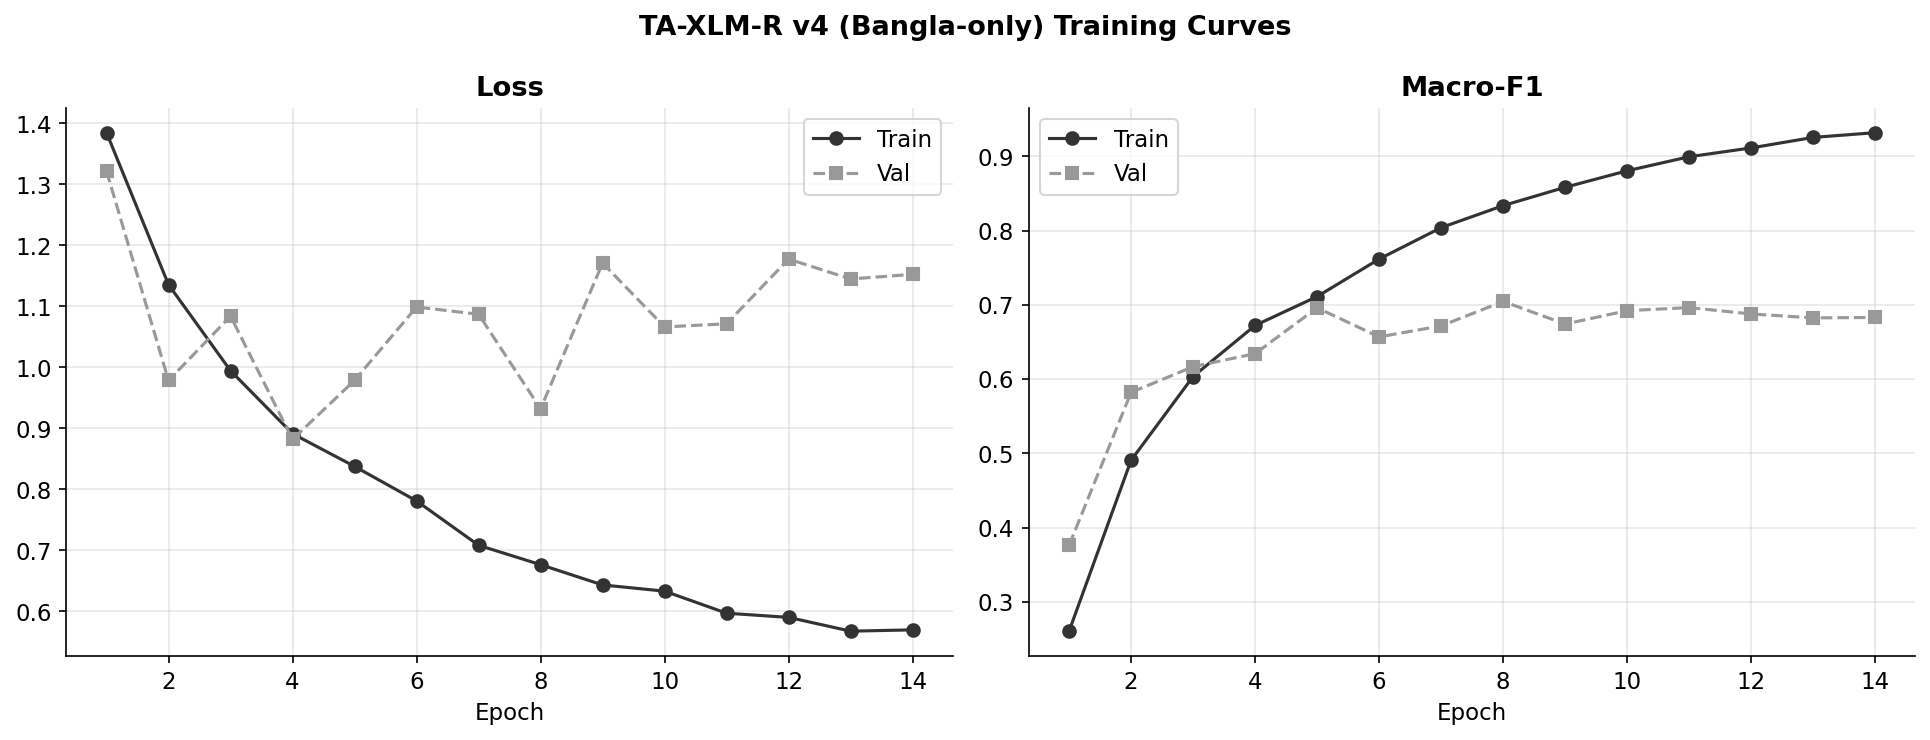

In [16]:
hist     = all_histories[best_seed_idx]
ep_range = range(1, len(hist['train_loss']) + 1)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, (tr_key, vl_key), title in zip(
    axes,
    [('train_loss', 'val_loss'), ('train_f1', 'val_f1')],
    ['Loss', 'Macro-F1']
):
    ax.plot(ep_range, hist[tr_key], '-o', color='0.2', label='Train', linewidth=1.5)
    ax.plot(ep_range, hist[vl_key], '--s', color='0.6', label='Val', linewidth=1.5)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.legend()

plt.suptitle('TA-XLM-R v4 (Bangla-only) Training Curves', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('training_curves_bangla.png', bbox_inches='tight')
plt.show()

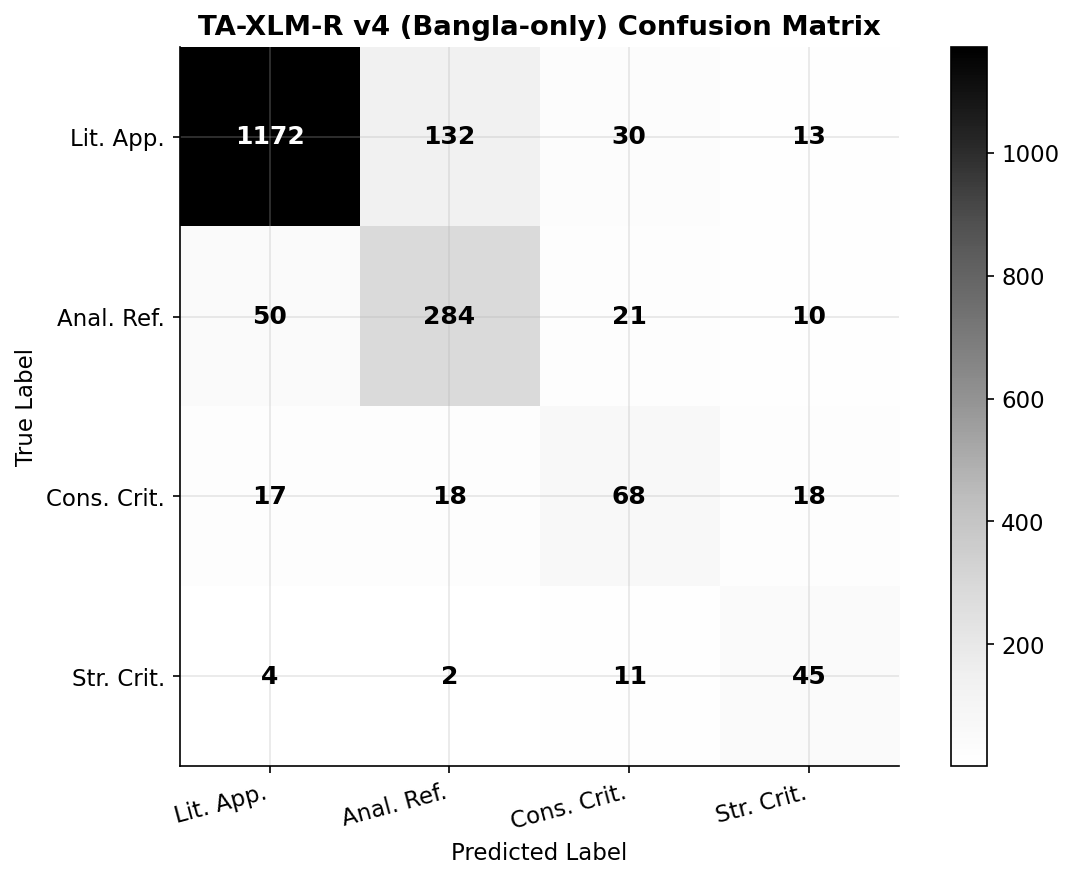

In [17]:
cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm, cmap='Greys')
plt.colorbar(im, ax=ax)
ax.set_xticks(range(4)); ax.set_yticks(range(4))
ax.set_xticklabels(SHORT_LBL, rotation=15, ha='right')
ax.set_yticklabels(SHORT_LBL)

thresh = cm.max() / 2
for i in range(4):
    for j in range(4):
        ax.text(j, i, str(cm[i, j]), ha='center', va='center',
                fontsize=12, fontweight='bold',
                color='white' if cm[i, j] > thresh else 'black')

ax.set_title('TA-XLM-R v4 (Bangla-only) Confusion Matrix', fontweight='bold')
ax.set_ylabel('True Label'); ax.set_xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('confusion_matrix_bangla.png', bbox_inches='tight')
plt.show()

## 13. Dataset Visualization
### Class distribution and text length analysis for Bangla-only subset

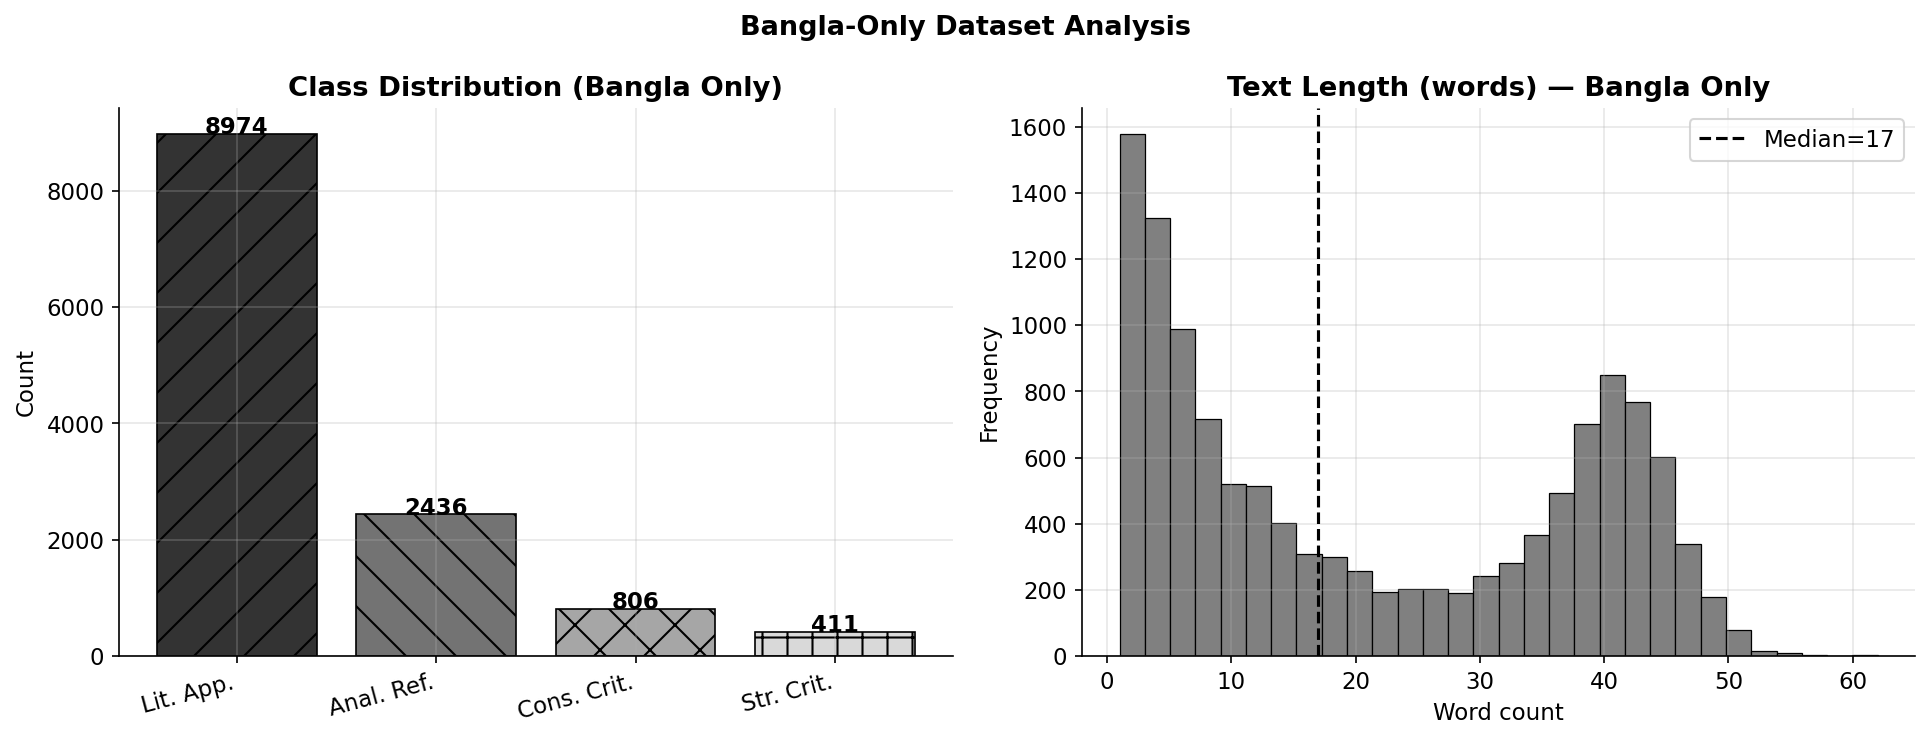

In [18]:
label_counts = df['label'].map(ID2LABEL).value_counts()

hatches = ['/', '\\', 'x', '+']
grays   = ['0.2', '0.45', '0.65', '0.85']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

bars = axes[0].bar(range(len(label_counts)), label_counts.values,
                   color=grays[:len(label_counts)], edgecolor='black', linewidth=0.8)
for bar, h in zip(bars, hatches):
    bar.set_hatch(h)
axes[0].set_xticks(range(len(label_counts)))
axes[0].set_xticklabels(SHORT_LBL, rotation=15, ha='right')
axes[0].set_title('Class Distribution (Bangla Only)', fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(label_counts.values):
    axes[0].text(i, v + 0.3, str(v), ha='center', fontweight='bold')

df['text_len'] = df['text_norm'].apply(lambda x: len(x.split()))
axes[1].hist(df['text_len'], bins=30, color='0.5', edgecolor='black', linewidth=0.6)
axes[1].set_title('Text Length (words) — Bangla Only', fontweight='bold')
axes[1].set_xlabel('Word count')
axes[1].set_ylabel('Frequency')
axes[1].axvline(df['text_len'].median(), color='black', linestyle='--',
                label=f'Median={df["text_len"].median():.0f}')
axes[1].legend()

plt.suptitle('Bangla-Only Dataset Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('dataset_analysis_bangla.png', bbox_inches='tight')
plt.show()